# Machine Learning Task 1: polynomial regression

*Updated 1/29/25*

#### We start by loading all the required packages. Sci-kit-learn or "sklearn" is the Python machine learning library.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
# reduce display precision on numpy arrays
np.set_printoptions(precision=1)
import pandas as pd
# reduce display precision on pandas dataframes
pd.set_option('display.precision', 1)
from sklearn import set_config
set_config(transform_output="pandas")
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, root_mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
import joblib

## Load data.
#### Load the [example data file](https://raw.githubusercontent.com/yanwu2001/DOE-ML-Public/main/PhysicalCatapult/ML_Catapult_ABC_y.csv) from GitHub first to check the codes.  The collective memory about this catapult is stored in [another file](https://raw.githubusercontent.com/yanwu2001/DOE-ML-Public/main/PhysicalCatapult/Catapult_ABCDEFGy_raw.csv) on GitHub. You can load that file later when you are ready to retrain the model with the most updated data.


In [2]:
#example data for ML task1 polynomial regression for intial run through is
#url='https://raw.githubusercontent.com/yanwu2001/DOE-ML-Public/main/PhysicalCatapult/ML_Catapult_ABC_y.csv'
#updated raw data url for retraining the model is
#url='https://raw.githubusercontent.com/yanwu2001/DOE-ML-Public/main/PhysicalCatapult/Catapult_ABCDEFGy_raw.csv'
# update the URL below as needed when retraining the model
url='https://raw.githubusercontent.com/yanwu2001/DOE-ML-Public/main/PhysicalCatapult/ML_Catapult_ABC_y.csv'
df=pd.read_csv(url)
print(df.head())
print(df.info())
print(df.describe())

     ID  Combo#  ball_mass  firing_height  band_length  launch_distance  \
0  run1       0       61.3           18.0         41.8            178.6   
1  run2       8       94.1           23.0         43.0            147.8   
2  run3       3       22.9           23.0         40.6            146.5   
3  run4       1       22.9           13.0         40.6            233.7   
4  run5       2       22.9           13.0         43.0            275.4   

  short_long  
0      short  
1      short  
2      short  
3       long  
4       long  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               100 non-null    object 
 1   Combo#           100 non-null    int64  
 2   ball_mass        100 non-null    float64
 3   firing_height    100 non-null    float64
 4   band_length      100 non-null    float64
 5   launch_distance  100 non-null

## Preparing the data
####We load a database, with each row corresponding to one data point: settings, and output. To use the data for machine learning,  we need to define our training label y_data, and the features of the input data, X_data.  

####More preparation of the data is needed to ensure that the code runs smoothly. This includes the following steps:

1. Exclude irrelevant features, such as ID and Combo#, as well as known fixed values.
2. Clean up any data with missing values by imputing those values. If the original dataset has no missing values, no changes will be made.




In [3]:
# Separate the predictors and the labels

# Define data for y_data by selecting the 'launch_distance' column
y_data=df['launch_distance'].copy()

# Get rid of non relevant data
X_data=df.drop(['ID','Combo#','launch_distance','short_long'],axis=1)

# Impute missing values with the mean of the that attrubute.
#  Other available strategies: "median", "most_frequent"
imputer = SimpleImputer(strategy='mean')
X_data = imputer.fit_transform(X_data)

## Split the data
#### Splitting into training, cross-validation, and test sets is a fundamental pracice in machine learning to ensure that the models are robust, generlizable, and reliable. If you train and evaluate the model on the same data, the model might learn the noise and details specific to that dataset rather than the underlying patterns. This results in overfitting, where the model performs well on the training data but poorly on the new, unseen data.

In [4]:
# Randomly, assign 60% of the dataset as the training set. Put the remaining 40% in temporary variables: x_ and y_.
X_train, X_, y_train, y_ = train_test_split(X_data, y_data, test_size=0.40, random_state=1)

# Randomly split the 40% subset above into two: one half for cross validation and the other for the test set
X_cv, X_test, y_cv, y_test = train_test_split(X_, y_, test_size=0.50, random_state=1)

# Delete the temporary variables
del X_, y_
print(f"the shape of the training set (input) is: {X_train.shape}")
print(f"the shape of the training set (target) is: {y_train.shape}\n")
print(f"the shape of the cross validation set (input) is: {X_cv.shape}")
print(f"the shape of the cross validation set (target) is: {y_cv.shape}\n")
print(f"the shape of the test set (input) is: {X_test.shape}")
print(f"the shape of the test set (target) is: {y_test.shape}")
print("the first 5 elements in X_train are :\n", X_train[:5])

the shape of the training set (input) is: (60, 3)
the shape of the training set (target) is: (60,)

the shape of the cross validation set (input) is: (20, 3)
the shape of the cross validation set (target) is: (20,)

the shape of the test set (input) is: (20, 3)
the shape of the test set (target) is: (20,)
the first 5 elements in X_train are :
     ball_mass  firing_height  band_length
86       68.5            7.4         47.3
53       94.1           19.0         42.0
77       22.9           14.2         33.0
15       22.9           13.0         43.0
83       61.3           10.4         39.5


## Scale the features.
#### Maching learning algorithms do not work perform well when the input numerical attributes have very different scales.  We will scale the input so that all features (input data) are roughly between -1 to 1.  The same scaling rule need to apply for new data or during production in order for the model to work.
#### Additionally, for some data sets it may be necessary to *transform* the target (output data), in order to compress or spread out the range of values. One example would be to take the natural logarithm of y; another example would be to take the square root. This can result in an improved model, in some cases.

In [5]:
# Pre-process the data before using it.
# Create a StandardScaler object for the training set, and use the same scaling for all data.
# The StandardScaler object transforms a range of values such that their mean=0 and standard deviation=1.
x_scaler = StandardScaler()
X = x_scaler.fit_transform(X_train)
# Never use .fit_transform for anything other than the training set.
# To ensure other data use the same tranformer, use .transform() [see example 2 blocks below, "Apply the same scaling and transformation"]

# X is now scaled training data inputs.
print(X.head())
print(X.describe())
#
y=y_train
# Or, transform the y output varible. The FunctionTransformer uses numpy objects (np).
#  Possible options include {np.log and np.exp}, or {np.sqrt and np.square}.
#y_transformer = FunctionTransformer(np.log, inverse_func=np.exp)
#y_train_tr = y_transformer.fit_transform(y_train)
#y=y_train_tr
# Again, never use .fit_transform for anything other than the training set.
# To ensure other data use the same tranformer, use .transform() [see example 2 blocks below, "Apply the same scaling and transformation"]

print(y.head())

    ball_mass  firing_height  band_length
86        0.4           -1.4      9.9e-01
53        1.2            0.7     -5.9e-02
77       -1.1           -0.2     -1.8e+00
15       -1.1           -0.4      1.4e-01
83        0.1           -0.8     -5.5e-01
       ball_mass  firing_height  band_length
count    6.0e+01        6.0e+01      6.0e+01
mean    -1.3e-16       -4.3e-17     -3.2e-16
std      1.0e+00        1.0e+00      1.0e+00
min     -1.1e+00       -1.5e+00     -1.8e+00
25%     -1.1e+00       -8.4e-01     -3.4e-01
50%      1.2e-01       -1.5e-01      4.1e-02
75%      1.2e+00        8.3e-01      7.4e-01
max      1.2e+00        1.4e+00      1.9e+00
86    212.2
53    165.0
77     73.9
15    254.0
83    184.6
Name: launch_distance, dtype: float64


## Linear Model
#### We will first train a linear model (1st order polynomial).

In [6]:
# 1st order model
# First, define the model type (LinearRegression, here).
model1 = LinearRegression()
# Then, train the model by fitting X data to y.
model1.fit(X,y)
# Never use .fit for anything other than the training set.
print("the fitting parameters for the 1st order model are:\n")
print("the weights are ", model1.coef_)
print("the intercept is", model1.intercept_)

# Use the model to make predictions on the training data
y_pred_tr = model1.predict(X)
# Transform y back, if necessary.
#y_pred_tr = y_transformer.inverse_transform(y_pred_tr)

# Now evaluate the quality of the fit by comparing predicted outputs to actual outputs.
# Calculate Root Mean Squared Error by selecting squared=False (the default is Mean Squared Error)
mse_t = root_mean_squared_error(y_train, y_pred_tr)
# Print the RMSE
print('Root Mean Squared Error for training set:', mse_t)

the fitting parameters for the 1st order model are:

the weights are  [-20.6 -35.6  74.4]
the intercept is 205.79333333333338
Root Mean Squared Error for training set: 40.0958720166386


## Evaluate this linear model with the cross-validation set.
####This helps in estimating the model's generalization ability, reducing the risk of overfitting or underfitting.

Note: In metrology, uncertainty quantifies the confidence in a measurement's accuracy due to inherent variability and limitations in measurement tools. Similarly, cross-validation provides an estimate of a model’s uncertainty by evaluating its performance across different subsets of data. The most common technique, k-fold cross-validation, partitions the dataset into k subsets, using each one as a test set while training on the remaining k-1 folds. Each validation round gives a different performance measure, and their variability reflects how much the model's accuracy depends on the specific dataset used. By averaging the cross-validation results and analyzing their spread (e.g., standard deviation of accuracy scores), we get a measure similar to uncertainty in measurement, helping assess how reliable the model's predictions are on unseen data. Instructions for using the k-fold technique are covered in another notebook (ipynb file).

In [7]:
# Apply the same scaling and transformation to the cross-validation inputs.
X_scaled_cv = x_scaler.transform(X_cv)

# Use model1 to make predictions on the cross validation data.
y_pred_cv = model1.predict(X_scaled_cv)
# Transform y back, if necessary.
#y_pred_cv = y_transformer.inverse_transform(y_pred_cv)

# Calculate Root Mean Squared Error
mse_cv = root_mean_squared_error(y_cv, y_pred_cv)
# Print the RMSE
print('Root Mean Squared Error for cross validation set:', mse_cv)

Root Mean Squared Error for cross validation set: 42.787780021741796


#### These RMSEs are comparable, but large: let's see if a more complicated model will improve things.
## Second order polynomial regression
#### By increasing the *order* of the polynomial model, we will reduce the bias of the model and avoid underfitting.
#### First, prepare the inputs (X data) for polynomial fitting.
#### This involves (1)  transforming the input data to produce polynomial features (i.e. from {X1, X2, ...} to {X1^2, X2^2, X1X2, ...}), *and* (2) scaling the polynomial features to be 0-mean, ±1 standard deviation.

In [8]:
# 2nd order polynomial regression - *data preparation*

# 1. Create a PolynomialFeatures object with degree 2, without bias (no first column of "1"s)
# The PolynomialFeatures object, here, creates a 2nd order,
#  The expanded set of features becomes: A, B, C, A^2, AB, AC, B^2, BC, C^2 -- i.e. added 2nd-order terms
poly = PolynomialFeatures(degree=2,include_bias=False)

# Use the PolynomialFeatures object to transform the data to create the polynomial features
X_poly = poly.fit_transform(X_train)
# Check the original and polynomial features
print("Original X:", X_train.head())
print("Polynomial X:", X_poly.head())

# 2. Now, Scale ("standardize") the training set, scaling each column so its mean=0, stdev=1
#  (It is best practice to scale the squared values, NOT to square the scaled values.)
poly_scaler = StandardScaler()
X2nd = poly_scaler.fit_transform(X_poly)
# X is scaled data prepped for a polynomial model.
y2nd=y_train

# Check the polynomial and scaled polynomial features
#print("Polynomial X:", X_poly.head())
print("SCALED Polynomial X:", X2nd.head())
print("Scaled, descriptions:",X2nd.describe())

Original X:     ball_mass  firing_height  band_length
86       68.5            7.4         47.3
53       94.1           19.0         42.0
77       22.9           14.2         33.0
15       22.9           13.0         43.0
83       61.3           10.4         39.5
Polynomial X:     ball_mass  firing_height  band_length  ball_mass^2  \
86       68.5            7.4         47.3       4692.2   
53       94.1           19.0         42.0       8854.8   
77       22.9           14.2         33.0        524.4   
15       22.9           13.0         43.0        524.4   
83       61.3           10.4         39.5       3757.7   

    ball_mass firing_height  ball_mass band_length  firing_height^2  \
86                    506.9                 3240.0             54.8   
53                   1787.9                 3952.2            361.0   
77                    325.2                  755.7            201.6   
15                    297.7                  984.7            169.0   
83                

#### Now that the data has been prepared, build the higher-order model.
#### Fit the training data, and compute the RMSE.

In [9]:
# Now, train the 2nd order model; as done 3 blocks above, in "1st order model"
model2 = LinearRegression()
model2.fit(X2nd,y2nd)
print("the fitting parameters for the 2nd order model are:\n")
print("the weights are ", model2.coef_)
print("the intercept is", model2.intercept_)

# Predict on the training data
y_pred_tr2 = model2.predict(X2nd)
# Calculate Root Mean Squared Error
mse_t = root_mean_squared_error(y_train, y_pred_tr2)
# Print the RMSE
print('Root Mean Squared Error for training set:', mse_t)

the fitting parameters for the 2nd order model are:

the weights are  [-73.   49.3 183.3  81.6  36.5 -60.8 -42.4 -68.8 -77.9]
the intercept is 205.79333333333315
Root Mean Squared Error for training set: 35.295770592164594


#### While the RMSE did get smaller from the results of the "1st order model" block - thus reducing bias - we need to verify that it didn't overfit (and create large variance).
#### We check this by using cross validation set.

In [10]:
# Transform, scale, and then fit the cross validation data (X_cv)

# 1. First, transform to create polynomial features.
#  Re-use the "poly" object created two blocks above, to create the polynomial features on X_cv.
X_poly_cv = poly.fit_transform(X_cv)
# Check the original and polynomial features
#print("Original X:", X_cv.head())
#print("Polynomial X:", X_poly.head())

# 2. Scale the transformed cross validation set, using the same "poly_scaler" object created two blocks above.
X2nd_cv = poly_scaler.transform(X_poly_cv)

# 3. Now, predict on the "prepared" cross validation data, using model2 created above:
y_pred_cv2 = model2.predict(X2nd_cv)

# Calculate Root Mean Squared Error
mse_cv = root_mean_squared_error(y_cv, y_pred_cv2)
# Print the RMSE
print('Root Mean Squared Error for cross validation set:', mse_cv)

Root Mean Squared Error for cross validation set: 42.62437414624094


#### By using a 2nd order model, we see a decrease in RMSE in the training set.
#### Meanwhile, the RMSE of the cross validation set does not increase. That is good news.  
## Pipeline
#### Going forward, we can use of make_pipeline to *streamline* the data processing & model fitting steps.

In [11]:
# Transforming and scaling each new dataset that we want to put into our model can get tiresome!
#  We can build a "pipeline" to streamline this process.
# make_pipeline "chains together" estimators (process steps).
#  Compare to the process shown 3 blocks above & 2 blocks above.
#    (titled "2nd order polynomial regression - data preparation" and "Now, train the 2nd order model")

#   First, the PolynomialFeatures & StandardScaler, done in this order:
preprocessing=make_pipeline(PolynomialFeatures(degree=2,include_bias=False),StandardScaler())

# Next, add the LinearRegression to the pipeline. Define the model, and add it to the pipeline.
model_pipe=LinearRegression()
train_pipe=make_pipeline(preprocessing,model_pipe)

# Finally, USE the pipeline to train the model
train_pipe.fit(X_train,y_train)
print("the fitting parameters for the 2nd order model are:\n")
print("the weights are ", train_pipe[-1].coef_)
print("the intercept is", train_pipe[-1].intercept_)

# Check MSE for training data. using the pipeline "train_pipe":
y_pred_tr=train_pipe.predict(X_train)
mse_tr = root_mean_squared_error(y_train, y_pred_tr)
# Print the RMSE
print('Root Mean Squared Error for training set:', mse_tr)

# Now that the pipeline is built, we can use it directly on the cross-validation data (X_cv).
#  The next two lines do the same as the *ENTIRE* preceding block, "Transform, scale, and then fit the cross validation data (X_cv) "
y_pred_cv=train_pipe.predict(X_cv) # transform, scale & predict: all in one line!
# Check RMSE for cross-validation data:
mse_cv = root_mean_squared_error(y_cv, y_pred_cv)
# Print the RMSE
print('Root Mean Squared Error for cross validation set:', mse_cv)

the fitting parameters for the 2nd order model are:

the weights are  [-73.   49.3 183.3  81.6  36.5 -60.8 -42.4 -68.8 -77.9]
the intercept is 205.79333333333315
Root Mean Squared Error for training set: 35.295770592164594
Root Mean Squared Error for cross validation set: 42.62437414624094


#### The above block shows that the pipeline does the same processsing steps, except that once the model is trained, you ONLY use it to predict: do NOT retrain by calling train_pipe.fit(X_cv,y_cv)!
#### With the help of pipeline, we can quickly try higher order models without having to write a lot of code.
#### This is illustrated below.

In [12]:
# Initialize lists of RMSEs to save the errors
train_mses = []
cv_mses = []
# Loop over 9 times. Each adding one more degree of polynomial higher than the last.
for degree_num in range(1,10):
  preprocessing=make_pipeline(PolynomialFeatures(degree=degree_num,include_bias=False),StandardScaler())
  model=LinearRegression()
  train_pipe=make_pipeline(preprocessing,model)
  train_pipe.fit(X_train,y_train)
  #evaluate training set prediction
  y_pred_tr=train_pipe.predict(X_train)
  mse_tr = root_mean_squared_error(y_train, y_pred_tr)
  train_mses.append(mse_tr)
  #evaluate cross validation set prediction
  y_pred_cv=train_pipe.predict(X_cv)
  mse_cv = root_mean_squared_error(y_cv, y_pred_cv)
  cv_mses.append(mse_cv)

print(train_mses)
print(cv_mses)

[40.095872016638594, 35.295770592164594, 14.55016635059613, 5.606275345215307, 5.514815903041955, 5.514815903041955, 5.514815903041955, 5.514815903041905, 5.51481590304192]
[42.78778002174179, 42.62437414624094, 20.777619331337338, 15.554243733640131, 124.44852005394122, 114.02159817149646, 103.9256527775734, 94.05046630197671, 84.56542565410271]


#### From the RMSEs, we see that as the polynomial order increases, the RMSE decreases until it gets rather small.
#### HOWEVER, we see that RMSE for the cross-validation data explodes at Degree=5!
#### Since the RMSE for training data is small at Degree=5, we surmise that the model is over-fit to the training data at Degree=5.
#### So, from the RMSEs we see that Degree=3 or Degree=4 are OK.  Let's next visialize the trend with plots.  

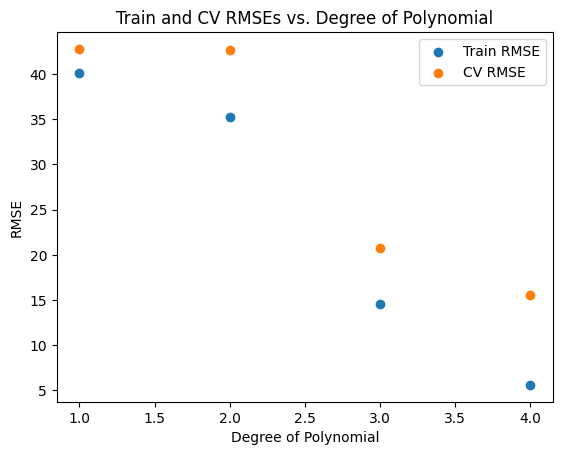

In [13]:
# Plot the results
plt.scatter(range(1,5), train_mses[0:4], label='Train RMSE')
plt.scatter(range(1,5), cv_mses[0:4], label='CV RMSE')
plt.xlabel('Degree of Polynomial')
plt.ylabel('RMSE')
plt.title('Train and CV RMSEs vs. Degree of Polynomial')
plt.legend()
plt.show()

#### As the order increases, training set RMSE decreases. CV set RMSE follows the trend but the gap between the two starts to increase at degree=4. We suspect the 3rd order model works the best... but let's "deploy" the model with the test data, next.

In [14]:
# DEPLOY the model as a trained predictor: build model, apply to TEST data.
## Try 4th order model first
preprocessing=make_pipeline(PolynomialFeatures(degree=4,include_bias=False),StandardScaler())
model=LinearRegression()
train_pipe4=make_pipeline(preprocessing,model)
train_pipe4.fit(X_train,y_train)
y_pred_test=train_pipe4.predict(X_test)
mse_t = root_mean_squared_error(y_test, y_pred_test)
print('Root Mean Squared Error for test set for 4th oder model:', mse_t)

Root Mean Squared Error for test set for 4th oder model: 42.49867270596109


#### Using the test set, we rule out the 4th order model. The RMSE is too big (and the model was over-fit to the training data).
#### Hopefully 3rd order is better!

In [15]:
# Deploy a 3rd order model (will keep as the final ML model)
preprocessing=make_pipeline(PolynomialFeatures(degree=3,include_bias=False),StandardScaler())
model=LinearRegression()
train_pipe3=make_pipeline(preprocessing,model)
train_pipe3.fit(X_train,y_train)
y_pred_test=train_pipe3.predict(X_test)
mse_t = root_mean_squared_error(y_test, y_pred_test)
print('Root Mean Squared Error for test set for 3rd oder model:', mse_t)

Root Mean Squared Error for test set for 3rd oder model: 32.07247067957224


#### Hooray! RMSE is "reasonable" and we will stick with the 3rd order model for this system, "train_pipe3".

## Saving the model for later
#### joblib.dump saves a "pickle" file in our working folder.  You can download it to your local drive.  This is your model from Machine Learning Task 1.  You can reload it in other codes to make predictions directly with new data. (The "joblib" library was installed in the 1st block, above.)

In [16]:
joblib.dump(train_pipe3, 'physical_catapult_regression.pkl')

['physical_catapult_regression.pkl']

#### The following shows how to Load and Use your saved model in other codes.

In [17]:
# 1. Load the saved model
final_model=joblib.load('physical_catapult_regression.pkl')

# 2. Use the now-loaded model.
y_pred_t=final_model.predict(X_test)

# Print data, predicted, and actual. Note that the data are NOT part of the saved model.
print("first 5 data points")
print(X_test.head())
print("the predicted launch distance")
print(y_pred_t[0:5])
print("the actual launch distance")
print(y_test.head())

first 5 data points
    ball_mass  firing_height  band_length
33       94.1            9.0         42.0
99       22.9           22.1         43.0
81       94.1            6.6         33.0
73       94.1            6.6         46.0
27       61.3           18.0         41.8
the predicted launch distance
[265.9 165.1  75.4 283.5 199.2]
the actual launch distance
33    264.0
99    177.9
81     72.1
73    281.7
27    176.5
Name: launch_distance, dtype: float64
